In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    

Using notebook 3d backend.


In [5]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        # 'LexicalNoDelay',
        'LexicalDelay',
        # 'PictureNaming',
        # 'SentenceRep',
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'

dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]

HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'
HGAs.head()

100%|██████████| 320/320 [00:05<00:00, 56.53it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0023_RPIF3-4,0.249398,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,41.901912,-28.228735,17.149502
1,-1.0,D0023_R2MF2-3,0.051112,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,11.195341,-7.769187,33.884895
2,-1.0,D0023_RPSF1-2,0.095070,False,CGs,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_S_pericallosal,6.423360,-15.496811,23.453189
3,-1.0,D0023_RPIF1-2,0.231350,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,35.187262,-26.860379,15.945394
4,-1.0,D0023_RPIF2-3,0.361105,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,38.280793,-27.303607,16.525972


In [6]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0040_L1IF2-3', 'D0040_L1IF3-4', 'D0079_LFAI1-2', 'D0079_LFAI2-3', 'D0079_LFMI1-2', 'D0079_LPI9-10', 'D0103_LAI7-8', 'D0103_LAI3-4', 'D0103_LAI5-6', 'D0103_LAI6-7']


In [7]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 74880
PIC electrode count: 67200


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0023_RPIF3-4,0.249398,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,41.901912,-28.228735,17.149502
1,-1.0,D0023_R2MF2-3,0.051112,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,11.195341,-7.769187,33.884895
2,-1.0,D0023_RPSF1-2,0.095070,False,CGs,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_S_pericallosal,6.423360,-15.496811,23.453189
3,-1.0,D0023_RPIF1-2,0.231350,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,35.187262,-26.860379,15.945394
4,-1.0,D0023_RPIF2-3,0.361105,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,38.280793,-27.303607,16.525972


# Load data

In [8]:
bids_root = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/'

In [9]:
def extract_reaction_time(epos_df):
    """
    Extract trial-level metadata and reaction time (RT) from a long-format epos DataFrame.
    
    Parameters
    ----------
    epos_df : pd.DataFrame
        Long-format DataFrame with columns:
        ['subject', 'epoch', 'condition', 'description', 'phase', 'onset', 'remark', ...]
        Each row corresponds to a single timepoint within an epoch.
    
    Returns
    -------
    epoch_tbl : pd.DataFrame
        Trial-level table (one row per epoch) with the following columns:
        - subject, epoch, condition, description, phase, onset, remark
        - trial : unique trial number (within each subject)
        - rt    : reaction time (resp_onset - go_onset) for the trial
        Only correct trials are retained.
    """
    # ----------------------------------------------------------------------
    # 1) Build a trial-level table from epoch-level metadata (one row per epoch)
    # ----------------------------------------------------------------------
    epoch_tbl = (
        epos_df[['subject', 'epoch', 'condition', 'description', 'phase', 'onset', 'remark']]
        .drop_duplicates()
    )

    # ----------------------------------------------------------------------
    # 2) Assign a unique trial number (trial) to each real trial.
    #    - Trials are defined by the onset of the Stimulus phase.
    #    - Within each subject, we count Stimulus events in chronological order.
    # ----------------------------------------------------------------------
    epoch_tbl = epoch_tbl.sort_values(['subject', 'onset', 'epoch']).reset_index(drop=True)

    epoch_tbl['trial'] = (
        epoch_tbl
        .groupby(['subject'], sort=False)['phase']
        .transform(lambda s: s.eq('Stimulus').cumsum())
    )
    # Rows before the first Stimulus (if any) will have trial=0; set them to NaN.
    epoch_tbl.loc[epoch_tbl['trial'].eq(0), 'trial'] = np.nan

    # ----------------------------------------------------------------------
    # 3) Extract Go and Response onsets for each trial and compute RT.
    #    - Pivot the long table so each trial has one row with go_onset and resp_onset.
    #    - RT = resp_onset - go_onset.
    # ----------------------------------------------------------------------
    go_resp_onset = (
        epoch_tbl[epoch_tbl['phase'].isin(['Go', 'Response'])]
        .pivot_table(
            index=['subject', 'description', 'trial', 'condition'],
            columns='phase',
            values='onset',
            aggfunc='first'
        )
        .reset_index()
        .rename(columns={'Go': 'go_onset', 'Response': 'resp_onset'})
    )

    go_resp_onset['rt'] = go_resp_onset['resp_onset'] - go_resp_onset['go_onset']

    # ----------------------------------------------------------------------
    # 4) Merge RT back into the epoch-level table.
    #    - Use subject, description, trial, and condition as the join key.
    # ----------------------------------------------------------------------
    epoch_tbl = epoch_tbl.merge(
        go_resp_onset[['subject', 'description', 'trial', 'condition', 'rt']],
        on=['subject', 'description', 'trial', 'condition'],
        how='left'
    )

    return epoch_tbl

In [10]:
mne.set_log_level('WARNING')
phases = ['Stimulus','Delay', 'Go', 'Response']
conditions = ['Decision','Repeat']

subset = HGAs[
    (HGAs.roi.isin(['PIC','AIC','STG','SMC','dACC',
                    'ITG','SMG','MTG','IFG','SFG',
                    'MFG','STS','AG','SPL','IPL','HG'
                ]))
    &(HGAs.task=='LexicalDelay')
]

# Container for all subjects' trial-level tables
epos = []

for sub in tqdm(subset.subject.unique()):

    this_sub = []

    for phase in phases:
        
        picks = subset[subset.subject==sub].channel.unique().tolist()
        
        pt = BIDSPath(
            root=os.path.join(bids_root, 'derivatives', 'epoch(bipolar)'),
            subject=sub,
            datatype='epoch(band)(zscore)',
            processing=phase,
            suffix='highgamma',
            extension='.h5',
            check=False
        )

        for condition in conditions:
            epo_path = pt.update(description=condition).match()[0]
            dc_epo = mne.read_epochs(epo_path, verbose='error')
            onset = dc_epo.events[:, 0] / 2048
            dc_epo.metadata = pd.DataFrame({'onset': onset}, index=dc_epo.selection)
            dc_epo.pick(picks)
            df = dc_epo.to_data_frame(long_format=True, scalings={'seeg': 1}, verbose=False)
            meta = dc_epo.metadata.reset_index(names='epoch')  # epoch == selection
            df = df.merge(meta, on='epoch', how='left')

            # drop ch_type column
            df = df.drop(columns=['ch_type'])
            df['phase'] = phase
            df['description'] = condition
            df['subject'] = sub
            df['remark'] = df['condition'].str.split('/').str[4:].str.join('/')
            df['condition'] = df['condition'].str.split('/').str[2:4].str.join('/')
            
            this_sub.append(df)

    # Concatenate all phases for this subject and extract RT
    this_sub = pd.concat(this_sub, ignore_index=True)
    trial_meta = extract_reaction_time(this_sub)

    this_sub = this_sub.merge(
        trial_meta[['subject', 'description', 'epoch', 'trial', 'rt']],
        on=['subject', 'description', 'epoch'],
        how='left'
    )

    epos.append(this_sub)

# Concatenate across subjects (optional)
epos = pd.concat(epos, ignore_index=True)
# drop epoch column
epos = epos.drop(columns=['epoch'])

# drop the Stimulus/Response Phase since it's not usable in the RT analysis
epos = epos[~epos.phase.isin(['Stimulus','Response'])]

epos.head()

100%|██████████| 39/39 [14:52<00:00, 22.88s/it]


,condition,time,channel,value,onset,phase,description,subject,remark,trial,rt
1182080,Word/latin,-1.0,D0023_RPIF8-9,2.700536,1232.695312,Delay,Decision,D0023,ERR_TASK/YN_REP,1.0,0.808105
1182081,Word/latin,-1.0,D0023_RPIF9-10,2.544646,1232.695312,Delay,Decision,D0023,ERR_TASK/YN_REP,1.0,0.808105
1182082,Word/latin,-1.0,D0023_R2IF1-2,-0.556157,1232.695312,Delay,Decision,D0023,ERR_TASK/YN_REP,1.0,0.808105
1182083,Word/latin,-1.0,D0023_R2MF10-11,1.071400,1232.695312,Delay,Decision,D0023,ERR_TASK/YN_REP,1.0,0.808105
1182084,Word/latin,-1.0,D0023_R2MF9-10,-0.424756,1232.695312,Delay,Decision,D0023,ERR_TASK/YN_REP,1.0,0.808105


In [11]:
# 提取 Delay (time>0) 和 Go (time<0) 的神经特征
# 每个 trial 计算 mean 和 slope

from scipy.ndimage import gaussian_filter1d

def compute_slope(x, t):
    """线性回归斜率：y = a*t + b，返回 a"""
    if len(t) < 2:
        return np.nan
    return np.polyfit(t, x, 1)[0]

def smooth_gaussian(x, t, sigma_s=0.05):
    """对不等长序列做高斯平滑：sigma_s 以秒为单位"""
    if len(t) < 3:
        return x
    # 假设 t 基本等间隔，用中位数 dt 换算到 sample
    dt = np.median(np.diff(t))
    if not np.isfinite(dt) or dt <= 0:
        return x
    sigma_samples = sigma_s / dt
    if not np.isfinite(sigma_samples) or sigma_samples <= 0:
        return x
    return gaussian_filter1d(x, sigma=sigma_samples, mode='nearest')

# 平滑窗口：推荐 sigma=50ms（你可以在 20-100ms 之间扫一下）
SIGMA_S = 0.05

# 筛选感兴趣的时间窗
delay_data = epos[(epos['phase'] == 'Delay') & (epos['time'] > 0)]
go_data = epos[(epos['phase'] == 'Go') & (epos['time'] < 0)]

# 合并 Delay + Go 作为 "准备期"
prep_data = pd.concat([delay_data, go_data], ignore_index=True)

# 按 trial 聚合：mean 和 slope（先按 time 排序并平滑）
features = (
    prep_data
    .sort_values(['subject','description','trial','channel','time'])
    .groupby(['subject', 'description', 'trial', 'channel','rt'])
    .apply(
        lambda g: pd.Series(
            (lambda t, x: {
                'mean_hga': smooth_gaussian(x, t, sigma_s=SIGMA_S).mean(),
                'slope_hga': compute_slope(smooth_gaussian(x, t, sigma_s=SIGMA_S), t),
            })(g['time'].values, g['value'].values)
        ),
        include_groups=False,
    )
    .reset_index()
)

features.head()

,subject,description,trial,channel,rt,mean_hga,slope_hga
0,D0023,Decision,1.0,D0023_R1MF1-2,0.808105,-0.463475,-0.036286
1,D0023,Decision,1.0,D0023_R1MF14-15,0.808105,-0.175940,-0.015761
2,D0023,Decision,1.0,D0023_R2IF1-2,0.808105,0.223146,0.025968
3,D0023,Decision,1.0,D0023_R2IF2-3,0.808105,-0.173443,-0.077806
4,D0023,Decision,1.0,D0023_R2MF1-2,0.808105,0.337363,0.004389


In [12]:
# 单电极预测：10-fold CV + OLS p值（每个 channel 内部）
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

cv_rows = []

for channel in features['channel'].unique():
    dfc = features[features['channel'] == channel].copy()
    if len(dfc) < 50:
        continue

    X_raw = dfc[['mean_hga', 'slope_hga']].values
    y = dfc['rt'].values

    # 10-fold
    n_splits = min(10, len(dfc))
    if n_splits < 2:
        continue

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    y_pred_all = np.empty_like(y, dtype=float)

    for train_idx, test_idx in kf.split(X_raw):
        X_train_raw = X_raw[train_idx]
        X_test_raw = X_raw[test_idx]
        y_train = y[train_idx]

        mu = X_train_raw.mean(axis=0)
        sd = X_train_raw.std(axis=0, ddof=0)
        sd[sd == 0] = 1.0

        X_train = (X_train_raw - mu) / sd
        X_test = (X_test_raw - mu) / sd

        X_train = sm.add_constant(X_train)
        X_test = sm.add_constant(X_test)

        res = sm.OLS(y_train, X_train).fit()
        y_pred_all[test_idx] = res.predict(X_test)

    cv_r2 = r2_score(y, y_pred_all)
    cv_rmse = float(np.sqrt(mean_squared_error(y, y_pred_all)))

    # 全样本 OLS 取 p 值
    mu_all = X_raw.mean(axis=0)
    sd_all = X_raw.std(axis=0, ddof=0)
    sd_all[sd_all == 0] = 1.0
    X_std = (X_raw - mu_all) / sd_all
    X_std = sm.add_constant(X_std)

    res_full = sm.OLS(y, X_std).fit()
    mean_p = res_full.pvalues[1] if len(res_full.pvalues) > 1 else np.nan
    slope_p = res_full.pvalues[2] if len(res_full.pvalues) > 2 else np.nan

    cv_rows.append({
        'channel': channel,
        'r2': cv_r2,
        'rmse': cv_rmse,
        'n': len(dfc),
        'mean_p': mean_p,
        'slope_p': slope_p
    })

cv_results = pd.DataFrame(cv_rows)

# FDR 校正
_, cv_results['mean_p_fdr'], _, _ = multipletests(cv_results['mean_p'], method='fdr_bh')
_, cv_results['slope_p_fdr'], _, _ = multipletests(cv_results['slope_p'], method='fdr_bh')

cv_results.sort_values('r2', ascending=False).head(10)

,channel,r2,rmse,n,mean_p,slope_p,mean_p_fdr,slope_p_fdr
142,D0053_LPIF12-14,0.246496,0.341476,336,3.331203e-12,4.852002e-11,2.240234e-10,6.525942e-09
308,D0079_LPAM14-15,0.227520,0.402881,336,9.649924e-15,9.178003e-12,1.730553e-12,1.645922e-09
5,D0023_R2MF10-11,0.214136,0.406230,336,2.668088e-16,3.497592e-05,1.435431e-13,5.534426e-04
503,D0102_RFPI5-6,0.195094,0.238165,330,1.677660e-11,3.021435e-05,1.002868e-09,4.925854e-04
102,D0038_RPST14-15,0.193297,0.158886,336,2.083554e-02,1.753738e-16,7.139823e-02,9.435109e-14
6,D0023_R2MF9-10,0.187564,0.413040,336,5.005795e-13,6.667607e-07,3.847311e-11,2.989310e-05
28,D0027_LAMF1-2,0.177832,0.567555,336,1.426984e-15,6.897025e-03,3.838588e-13,3.503337e-02
367,D0084_RPI13-14,0.165577,0.498943,336,2.714409e-13,7.094656e-03,3.054403e-11,3.528391e-02
403,D0090_RIP5-6,0.151429,0.193170,296,7.395045e-10,6.965232e-06,2.652356e-08,1.561373e-04
31,D0027_LMSF6-7,0.136124,0.581773,336,2.526993e-10,7.764470e-02,1.045786e-08,2.071181e-01


# Load RT Prediction Results

In [13]:
subset = HGAs[['channel', 'roi','hemi','description','task','phase','label','x','y','z']].drop_duplicates()
cv_results = cv_results.merge(subset, on='channel', how='left')
cv_results.head()

,channel,r2,rmse,n,mean_p,slope_p,mean_p_fdr,slope_p_fdr,roi,hemi,description,task,phase,label,x,y,z
0,D0023_R1MF1-2,-0.020398,0.462895,336,9.549355e-01,0.816008,0.974868,0.920361,dACC,R,Repeat,LexicalDelay,go,ctx_rh_G_and_S_cingul-Mid-Ant,9.295536,5.962643,32.639046
1,D0023_R1MF14-15,0.075328,0.440648,336,8.355601e-07,0.001843,0.000015,0.013048,SMC,R,Decision,LexicalDelay,go,ctx_rh_G_precentral,56.249805,1.672702,35.132438
2,D0023_R1MF14-15,0.075328,0.440648,336,8.355601e-07,0.001843,0.000015,0.013048,SMC,R,Repeat,LexicalDelay,go,ctx_rh_G_precentral,56.249805,1.672702,35.132438
3,D0023_R1MF14-15,0.075328,0.440648,336,8.355601e-07,0.001843,0.000015,0.013048,SMC,R,Decision,LexicalDelay,response,ctx_rh_G_precentral,56.249805,1.672702,35.132438
4,D0023_R1MF14-15,0.075328,0.440648,336,8.355601e-07,0.001843,0.000015,0.013048,SMC,R,Repeat,LexicalDelay,response,ctx_rh_G_precentral,56.249805,1.672702,35.132438


In [14]:
cv_results = cv_results[cv_results.r2>0]

2026-01-20 15:00:31.522 (1490.423s) [    7FE053F71440]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-20 15:00:31.579 (1490.480s) [    7FE053F71440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x6982db0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-20 15:00:31.668 (1490.569s) [    7FE053F71440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x6982db0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D en

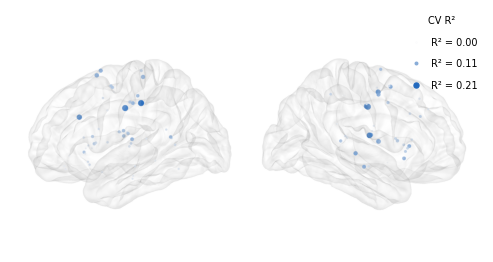

In [15]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree

df = cv_results.dropna(subset=['x','y','z', 'r2', 'mean_p_fdr']).copy()
df = df[df['mean_p_fdr'] < 0.01]

coords = df[['x','y','z']].values
vals = df['r2'].values

vmin = np.nanpercentile(vals, 2)
vmax = np.nanpercentile(vals, 98)
if not np.isfinite(vmin):
    vmin = np.nanmin(vals)
if not np.isfinite(vmax):
    vmax = np.nanmax(vals)
if vmin == vmax:
    vmax = vmin + 1e-6

cmap = blues
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

sizes = 10 + 25 * np.clip((vals - vmin) / (vmax - vmin), 0, 1)

lh_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_coords)
rh_tree = cKDTree(rh_coords)

lh = Brain('fsaverage', subjects_dir=recon_dir, hemi='lh', surf='pial', background='white', show=False, cortex=(0.9,0.9,0.9), alpha=0.15, size=(600*cm, 600*cm))
rh = Brain('fsaverage', subjects_dir=recon_dir, hemi='rh', surf='pial', background='white', show=False, cortex=(0.9,0.9,0.9), alpha=0.15, size=(600*cm, 600*cm))

mask_lh = coords[:, 0] < 0
mask_rh = coords[:, 0] > 0

if mask_lh.any():
    _, idx = lh_tree.query(coords[mask_lh])
    proj = lh_coords[idx]
    for pt, v, s in zip(proj, vals[mask_lh], sizes[mask_lh]):
        lh._renderer.plotter.add_mesh(pv.PolyData(pt.reshape(1,3)), render_points_as_spheres=True, point_size=float(s), color=cmap(norm(v))[:3], lighting=False, opacity=0.95)

if mask_rh.any():
    _, idx = rh_tree.query(coords[mask_rh])
    proj = rh_coords[idx]
    for pt, v, s in zip(proj, vals[mask_rh], sizes[mask_rh]):
        rh._renderer.plotter.add_mesh(pv.PolyData(pt.reshape(1,3)), render_points_as_spheres=True, point_size=float(s), color=cmap(norm(v))[:3], lighting=False, opacity=0.95)

for b in (lh, rh):
    b.show_view(view='lateral', distance=400)
    b._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]})
plt.subplots_adjust(wspace=-0.1)
ax1.imshow(lh.screenshot(mode='rgb'))
ax1.axis('off')
ax2.imshow(rh.screenshot(mode='rgb'))
ax2.axis('off')

# 添加图例 - 修复大小不一致问题
from matplotlib.lines import Line2D

# 创建示例 R² 值
example_r2 = [vmin, (vmin + vmax) / 2, vmax]
example_labels = [f'{vmin:.2f}', f'{(vmin + vmax) / 2:.2f}', f'{vmax:.2f}']

# 计算对应的大小（和脑图完全一致）
example_sizes = 1 + 35 * np.clip((np.array(example_r2) - vmin) / (vmax - vmin), 0, 1)

# 创建图例句柄 - 使用缩放因子匹配 PyVista 大小
handles = []
for r2_val, size, label in zip(example_r2, example_sizes, example_labels):
    # 调整缩放因子让 matplotlib markersize 匹配 PyVista point_size
    # 通过实验找到合适的缩放因子
    markersize = size * 0.1  # 调整这个因子来匹配脑图中的大小
    
    handle = Line2D(
        [0], [0], 
        marker='o', 
        linestyle='None',
        markerfacecolor=cmap(norm(r2_val)),
        markeredgecolor=cmap(norm(r2_val)),
        markersize=markersize,
        label=f'R² = {label}'
    )
    handles.append(handle)

# 添加图例到右侧图
ax2.legend(
    handles=handles,
    title='CV R²',
    loc='upper right',
    frameon=False,
    borderaxespad=0.2,
    handletextpad=0.6,
    labelspacing=1.2,
    fontsize=7,
    title_fontsize=7
)

lh.close()
rh.close()

fig.savefig(f'../img/fig4/fig4_RT_spatial.svg', dpi=300, bbox_inches='tight')

# Load results

In [3]:
ref = 'bipolar'

result_path = BIDSPath(
    datatype='RT',
    root=f'../results/LexicalDelay({ref})',
    suffix='highgamma',
    check=False
)

full_path = result_path.match()

rt = []

for path in tqdm(full_path):
    mat = h5py.File(path, 'r')
    
    # r2: (channels, time)
    r2 = mat['r2'][()]
    # time: (time,)
    time = mat['time'][()]
    # channels: (channels,)
    channels = [ch.decode('utf-8') for ch in mat['channels'][:]]
    # pval: (channels, time)
    pval = mat['pval'][()]
    # perm_r2: (channels, time, n_perm)
    perm_r2 = mat['perm_r2'][()]
    # cluster_pval: (channels, time)
    cluster_pval = mat['cluster_pval'][()]
    # mask: (channels, time)
    mask = mat['mask'][()]
    
    mat.close()
    
    n_channels, n_time = r2.shape
    
    # ---- 1) perm_r2 在 perm 维度上平均 → (channels, time) ----
    perm_r2_mean = perm_r2.mean(axis=-1)  # shape: (channels, time)
    
    # ---- 2) 宽表：每列一个 time point（r2）----
    df_r2 = pd.DataFrame(r2, index=channels, columns=time).reset_index()
    df_r2 = df_r2.rename(columns={'index': 'channel'})
    
    # 宽表 perm_r2_mean
    df_perm = pd.DataFrame(perm_r2_mean, index=channels, columns=time).reset_index()
    df_perm = df_perm.rename(columns={'index': 'channel'})
    
    # 宽表 pval
    df_pval = pd.DataFrame(pval, index=channels, columns=time).reset_index()
    df_pval = df_pval.rename(columns={'index': 'channel'})
    
    # 宽表 cluster_pval
    df_cluster_pval = pd.DataFrame(cluster_pval, index=channels, columns=time).reset_index()
    df_cluster_pval = df_cluster_pval.rename(columns={'index': 'channel'})
    
    # 宽表 mask
    df_mask = pd.DataFrame(mask, index=channels, columns=time).reset_index()
    df_mask = df_mask.rename(columns={'index': 'channel'})
    
    # ---- 3) 宽 → 长，显式保留 channel ----
    df_r2 = df_r2.melt(
        id_vars='channel',
        var_name='time',
        value_name='r2'
    )  # (channels * time, 3)
    
    df_perm = df_perm.melt(
        id_vars='channel',
        var_name='time',
        value_name='perm_r2_mean'
    )
    
    df_pval = df_pval.melt(
        id_vars='channel',
        var_name='time',
        value_name='pval'
    )
    
    df_cluster_pval = df_cluster_pval.melt(
        id_vars='channel',
        var_name='time',
        value_name='cluster_pval'
    )
    
    df_mask = df_mask.melt(
        id_vars='channel',
        var_name='time',
        value_name='mask'
    )
    
    # 合并所有指标（按 channel, time 对齐）
    df = df_r2.merge(df_perm, on=['channel', 'time'], how='left')
    df = df.merge(df_pval, on=['channel', 'time'], how='left')
    df = df.merge(df_cluster_pval, on=['channel', 'time'], how='left')
    df = df.merge(df_mask, on=['channel', 'time'], how='left')
    
    # ---- 4) 加上 path 的元信息 ----
    df['subject'] = path.subject
    df['phase'] = path.processing
    df['description'] = path.description
    df['band'] = path.suffix
    
    rt.append(df)

rt = pd.concat(rt, ignore_index=True)
rt.head()

100%|██████████| 320/320 [01:29<00:00,  3.57it/s]


,channel,time,r2,perm_r2_mean,pval,cluster_pval,mask,subject,phase,description,band
0,D0023_RMSF9-10,-0.8,-0.101244,-0.108767,0.512974,0.512974,False,D0023,Delay,Decision,highgamma
1,D0023_RMSF10-11,-0.8,-0.108002,-0.110652,0.580838,0.580838,False,D0023,Delay,Decision,highgamma
2,D0023_RPSF1-2,-0.8,-0.129464,-0.108076,0.810379,0.810379,False,D0023,Delay,Decision,highgamma
3,D0023_RPSF5-6,-0.8,-0.105526,-0.110362,0.512974,0.512974,False,D0023,Delay,Decision,highgamma
4,D0023_RPSF7-8,-0.8,-0.093885,-0.108835,0.395210,0.395210,False,D0023,Delay,Decision,highgamma


In [4]:
# load zscore to get electrode coordinates
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        # 'PhonemeSequence', 
        # 'LexicalNoDelay',
        'LexicalDelay',
        # 'PictureNaming',
        # 'SentenceRep'
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='zscore',
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'

HGAs.head()

100%|██████████| 320/320 [00:36<00:00,  8.75it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0023_RASF2-3,-0.058961,False,D0023,Decision,LexicalDelay,delay,sound,ctx_rh_S_orbital_med-olfact,OFCs,R,12.402980,30.517454,-18.923052
1,-1.0,D0023_RASF3-4,-0.002991,False,D0023,Decision,LexicalDelay,delay,sound,Right-Cerebral-White-Matter,WM,R,12.903507,31.300961,-14.787464
2,-1.0,D0023_RASF4-5,-0.035514,False,D0023,Decision,LexicalDelay,delay,sound,Right-Cerebral-White-Matter,WM,R,13.403986,32.084469,-10.651876
3,-1.0,D0023_RASF5-6,0.007915,False,D0023,Decision,LexicalDelay,delay,sound,Right-Cerebral-White-Matter,WM,R,13.989971,32.504692,-6.639220
4,-1.0,D0023_RASF6-7,-0.047390,False,D0023,Decision,LexicalDelay,delay,sound,Right-Cerebral-White-Matter,WM,R,14.281627,32.874982,-2.543640


In [5]:
coords = HGAs[['channel', 'roi','label', 'hemi','x', 'y', 'z']].drop_duplicates().reset_index(drop=True)
rt = rt.merge(coords, on='channel', how='left')

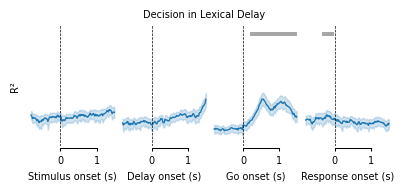

In [14]:
sig = rt[rt['mask'] == True].copy()

# 按 channel 分组，检查每个 channel 是否至少有一个显著时间点 (mask == True)
sig_channels = sig.groupby('channel').size() > 0
sig_channels = sig_channels[sig_channels].index.tolist()

sig_rt = rt[
    rt['channel'].isin(sig_channels)
].copy()


condition = 'Decision'
subset = sig_rt[(sig_rt.description==condition)]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(12*cm, 4*cm),
                                         gridspec_kw={'width_ratios': [2.5, 2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

ymax, pad, bar_h = 0.15, 0.01, 0.01
sig_threshold = 0.05  # 1%
# roi = 'Insula'

for (ax, phase) in zip(fig.axes, ['Stimulus', 'Delay', 'Go', 'Response']):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True
    
    g = subset[(subset.phase == phase)].groupby('channel')['r2']

    picks = (
        g.min().ge(-1) &   
        g.max().le(1) &    
        g.max().gt(0)     
    )
    
    picks = picks[picks].index

    line = sns.lineplot(
        data=subset[(subset.phase == phase) & (subset.channel.isin(picks))],
        x='time',
        y='r2',
        ax=ax,
        legend=legend,
        lw=1
    )
    
    
    sig_ratio = subset[(subset.phase == phase)].sort_values('time')
    sig_ratio = sig_ratio.groupby('time')['mask'].mean()
    
    aggregated_mask = sig_ratio >= sig_threshold
    
    
    if aggregated_mask.any():
        ax.fill_between(
            sig_ratio.index.values,
            ymax + pad,
            ymax + pad + bar_h,
            where=aggregated_mask.values,
            color='gray',
            alpha=0.7,
            step='mid',
            linewidth=0
        )

    
for ax in fig.axes:
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    # ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.15, ymax + pad + bar_h + 0.02)
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Delay onset (s)', fontsize=7)   
ax3.set_xlabel('Go onset (s)', fontsize=7)   
ax4.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('R²', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
ax4.set_ylabel('', fontsize=7)

plt.suptitle(f'{condition} in Lexical Delay', fontsize=7)
plt.savefig(f'../img/fig4/fig4_predict_rt_temporal.svg', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# 1. 筛选 significant 的电极
sig_channels = rt.loc[rt['mask'], 'channel'].unique()
sig_rt = rt[rt['channel'].isin(sig_channels)].copy()

# 2. 只看 Go phase + Repeat description
subset = sig_rt[(sig_rt.description=='Decision') & (sig_rt.phase=='Go')].copy()

# 3. 筛选动态范围在 [-1, 1] 且 max > 0 的电极
g = subset.groupby('channel')['r2']

picks = (
    g.min().ge(-1) &   # 最小值 >= -1
    g.max().le(1) &    # 最大值 <= 1
    g.max().gt(0)      # 最大值 > 0
)
picks = picks[picks].index  # ✅ 提取满足条件的 channel 列表

print(f"原始 significant 电极数: {len(sig_channels)}")
print(f"Go phase 中满足条件的电极数: {len(picks)}")

# 只保留满足条件的电极
subset = subset[subset.channel.isin(picks)].copy()

# 验证筛选结果
print("\n筛选后的 R² 统计:")
print(f"  Min: {subset['r2'].min():.4f}")
print(f"  Max: {subset['r2'].max():.4f}")
print(f"  每个 channel 的 max:")
channel_max = subset.groupby('channel')['r2'].max()
print(f"    所有 channel 的 max 都 > 0: {(channel_max > 0).all()}")
print(f"    Max 的范围: [{channel_max.min():.4f}, {channel_max.max():.4f}]")

# 聚合坐标信息
coords_ = subset.groupby('channel').agg({
    'r2': 'max',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
}).reset_index()

coords_.head()

原始 significant 电极数: 606
Go phase 中满足条件的电极数: 192

筛选后的 R² 统计:
  Min: -0.7284
  Max: 0.4908
  每个 channel 的 max:
    所有 channel 的 max 都 > 0: True
    Max 的范围: [0.0002, 0.4908]


,channel,r2,x,y,z,roi,label,phase,hemi,subject
0,D0023_R1MF1-2,0.227434,9.295536,5.962643,32.639046,CG,ctx_rh_G_and_S_cingul-Mid-Ant,Go,R,D0023
1,D0023_R2IF2-3,0.039099,36.686262,-8.172090,19.151989,Insula,ctx_rh_S_circular_insula_sup,Go,R,D0023
2,D0023_R2MF1-2,0.055760,7.071022,-7.307247,33.304338,CG,ctx_rh_G_and_S_cingul-Mid-Ant,Go,R,D0023
3,D0023_R2MF10-11,0.084440,40.025482,-8.423863,36.077959,SMC,ctx_rh_S_precentral-inf-part,Go,R,D0023
4,D0023_R2MF9-10,0.254172,36.417728,-8.358371,36.078040,SMC,ctx_rh_S_precentral-inf-part,Go,R,D0023


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-26 11:40:40.526 (2057.441s) [    7FC5556A0440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x18abfb20): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-26 11:40:40.598 (2057.513s) [    7FC5556A0440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x18abfb20): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

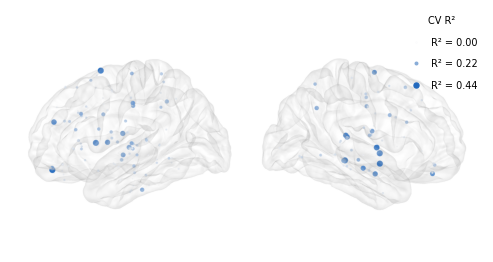

In [16]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree


coords = coords_[['x','y','z']].values
vals = coords_['r2'].values

vmin = np.nanpercentile(vals, 2)
vmax = np.nanpercentile(vals, 98)
if not np.isfinite(vmin):
    vmin = np.nanmin(vals)
if not np.isfinite(vmax):
    vmax = np.nanmax(vals)
if vmin == vmax:
    vmax = vmin + 1e-6

cmap = blues
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

sizes = 10 + 25 * np.clip((vals - vmin) / (vmax - vmin), 0, 1)

lh_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_coords)
rh_tree = cKDTree(rh_coords)

lh = Brain('fsaverage', subjects_dir=recon_dir, hemi='lh', surf='pial', background='white', show=False, cortex=(0.9,0.9,0.9), alpha=0.15, size=(600*cm, 600*cm))
rh = Brain('fsaverage', subjects_dir=recon_dir, hemi='rh', surf='pial', background='white', show=False, cortex=(0.9,0.9,0.9), alpha=0.15, size=(600*cm, 600*cm))

mask_lh = coords[:, 0] < 0
mask_rh = coords[:, 0] > 0

if mask_lh.any():
    _, idx = lh_tree.query(coords[mask_lh])
    proj = lh_coords[idx]
    for pt, v, s in zip(proj, vals[mask_lh], sizes[mask_lh]):
        lh._renderer.plotter.add_mesh(pv.PolyData(pt.reshape(1,3)), render_points_as_spheres=True, point_size=float(s), color=cmap(norm(v))[:3], lighting=False, opacity=0.95)

if mask_rh.any():
    _, idx = rh_tree.query(coords[mask_rh])
    proj = rh_coords[idx]
    for pt, v, s in zip(proj, vals[mask_rh], sizes[mask_rh]):
        rh._renderer.plotter.add_mesh(pv.PolyData(pt.reshape(1,3)), render_points_as_spheres=True, point_size=float(s), color=cmap(norm(v))[:3], lighting=False, opacity=0.95)

for b in (lh, rh):
    b.show_view(view='lateral', distance=400)
    b._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]})
plt.subplots_adjust(wspace=-0.1)
ax1.imshow(lh.screenshot(mode='rgb'))
ax1.axis('off')
ax2.imshow(rh.screenshot(mode='rgb'))
ax2.axis('off')

# 添加图例 - 修复大小不一致问题
from matplotlib.lines import Line2D

# 创建示例 R² 值
example_r2 = [vmin, (vmin + vmax) / 2, vmax]
example_labels = [f'{vmin:.2f}', f'{(vmin + vmax) / 2:.2f}', f'{vmax:.2f}']

# 计算对应的大小（和脑图完全一致）
example_sizes = 1 + 35 * np.clip((np.array(example_r2) - vmin) / (vmax - vmin), 0, 1)

# 创建图例句柄 - 使用缩放因子匹配 PyVista 大小
handles = []
for r2_val, size, label in zip(example_r2, example_sizes, example_labels):
    # 调整缩放因子让 matplotlib markersize 匹配 PyVista point_size
    # 通过实验找到合适的缩放因子
    markersize = size * 0.1  # 调整这个因子来匹配脑图中的大小
    
    handle = Line2D(
        [0], [0], 
        marker='o', 
        linestyle='None',
        markerfacecolor=cmap(norm(r2_val)),
        markeredgecolor=cmap(norm(r2_val)),
        markersize=markersize,
        label=f'R² = {label}'
    )
    handles.append(handle)

# 添加图例到右侧图
ax2.legend(
    handles=handles,
    title='CV R²',
    loc='upper right',
    frameon=False,
    borderaxespad=0.2,
    handletextpad=0.6,
    labelspacing=1.2,
    fontsize=7,
    title_fontsize=7
)

lh.close()
rh.close()

# fig.savefig(f'../img/fig4/fig4_RT_spatial.svg', dpi=300, bbox_inches='tight')